In [1]:
'''
this notebook demonstrates the following:
1. when hebbian patterns are heavily tailed then instead of converging to a pattern, network typically converges to a pattern mixture.
2. gentle strengthening or weakening patterns by e.g. 10% will shift the point of attraction to slightly different mixture rather than make it stick to one of the patterns.
3. introduce a learning algo where a new pattern is stored each time that the new pattern is mostly not explained out by the existing patterns.  
'''

'\nthis notebook demonstrates the following:\n1. when hebbian patterns are heavily tailed then instead of converging to a pattern, network typically converges to a pattern mixture.\n2. gentle strengthening or weakening patterns by e.g. 10% will shift the point of attraction to slightly different mixture rather than make it stick to one of the patterns.\n3. introduce a learning algo where a new pattern is stored each time that the new pattern is mostly not explained out by the existing patterns.  \n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def generate_patterns(distribution, num_patterns, pattern_size):
    if distribution == 'gaussian':
        return np.random.randn(num_patterns, pattern_size)
    elif distribution == 'laplace':
        return np.random.laplace(loc=0.0, scale=1.0, size=(num_patterns, pattern_size))
    else:
        raise ValueError("Unsupported distribution type")

In [4]:
def run_dynamics(x0, #[n_k,n] 
                 W, #[n,n]
                 phi, 
                 g=2, num_steps=100):
    x = x0
    xt = np.zeros((num_steps+1, *x.shape)) #[num_steps+1,n_k,n]
    xt[0, :, :] = x
    for t in range(1, num_steps+1):
        x = phi(g * (x @ W)) #[n_k,n]
        xt[t, :, :] = x
    return x, xt

In [5]:
def create_hebbian_weights(patterns, pattern_weights=None, normalize=True):
    if pattern_weights is not None:
        pattern_weights  = np.eye(p) + np.diag(pattern_weights_deltas)
        W = xi.T @ pattern_weights @ xi #[n,n]
    else:
        W = xi.T @ xi #[n,n]
    if normalize:
        W /= patterns.shape[1]  # Normalize by the number of neurons
    return W

In [6]:
phi = np.tanh
n = 10000
p = 7
xi = generate_patterns('laplace', p, n)


In [7]:
''' 
gnenerate random initial states in the positive orthant and see where they converge to.
'''
n_k = 40 #number of initial states to test
bnd_off_zero = 0.1
k = np.random.rand(n_k,p)*(1-bnd_off_zero) + bnd_off_zero #random initial mixture weights
'L2 normalize the rows of k to have unit norm'
k = k / np.linalg.norm(k, axis=1, keepdims=True)

x0 = k @ xi #random initial states as random mixtures of the patterns


perturb_amp = 0.15
dim_to_perturb = [None] + list(range(p)) #the first entry corresponds to no perturbation, then we will perturb each pattern in turn

all_projs = []

for dd, this_dim_to_perturb in enumerate(dim_to_perturb):
    pattern_weights_deltas = np.zeros(p)
    if this_dim_to_perturb is not None:
        pattern_weights_deltas[this_dim_to_perturb] = perturb_amp
    W = create_hebbian_weights(xi, pattern_weights_deltas)
    final_states, trajectories = run_dynamics(x0, W, phi, g=1.05, num_steps=100)
    all_projs.append(trajectories @ xi.T)




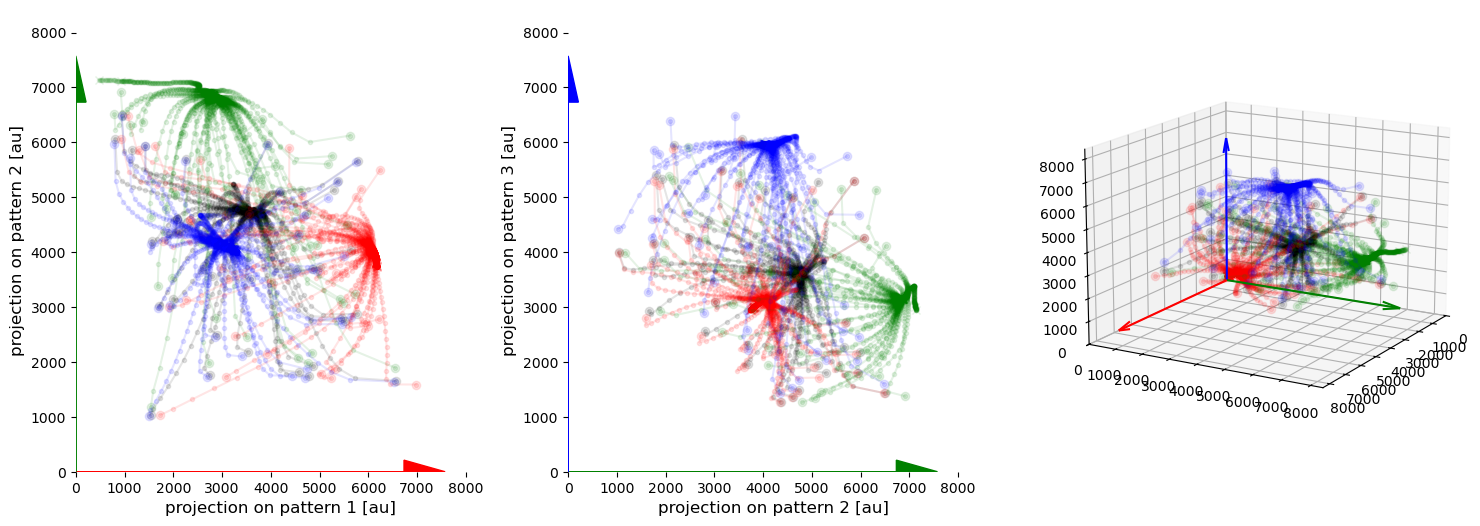

In [8]:
colors = ['k', 'r', 'g', 'b']
plt.figure(figsize=(18, 6))
lim = 1.1*np.max(np.abs((all_projs))[:,1:])
for dd, this_dim_to_perturb in enumerate(dim_to_perturb[:4]):
    projs = all_projs[dd][1:]
    for i in range(n_k):
        plt.subplot(1, 3, 1)
        plt.plot(projs[:, i, 0], projs[:, i, 1],'.-', alpha=0.1, color=colors[dd])
        plt.plot(projs[-1, i, 0], projs[-1, i, 1],'x', alpha=0.1, color=colors[dd])
        plt.plot(projs[0, i, 0], projs[0, i, 1],'o', alpha=0.1, color=colors[dd])
        plt.xlim(0, lim)
        plt.ylim(0, lim)
        plt.xlabel('projection on pattern 1 [au]', fontsize=12)
        plt.ylabel('projection on pattern 2 [au]', fontsize=12)
        plt.subplot(1, 3, 2)
        plt.plot(projs[:, i, 1], projs[:, i, 2],'.-', alpha=0.1, color=colors[dd])
        plt.plot(projs[-1, i, 1], projs[-1, i, 2],'x', alpha=0.1, color=colors[dd])
        plt.plot(projs[0, i, 1], projs[0, i, 2],'o', alpha=0.1, color=colors[dd])
        plt.xlim(0, lim)
        plt.ylim(0, lim)
        plt.xlabel('projection on pattern 2 [au]', fontsize=12)
        plt.ylabel('projection on pattern 3 [au]', fontsize=12)
        #3D plotting
        ax = plt.subplot(1, 3, 3, projection='3d')
        ax.plot(projs[:, i, 0], projs[:, i, 1], projs[:, i, 2],'.-', alpha=0.1, color=colors[dd])
        ax.plot(projs[-1, i, 0], projs[-1, i, 1], projs[-1, i, 2],'x', alpha=0.1, color=colors[dd])
        ax.plot(projs[0, i, 0], projs[0, i, 1], projs[0, i, 2],'o', alpha=0.1, color=colors[dd])
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_zlim(0, lim)
        ax.view_init(15, 30, 0)
#for each subplot draw arrows along the axes in the colors corresponding to the perturbations

plt.subplot(1, 3, 1)
plt.arrow(0, 0, lim*0.8, 0, head_width=lim*0.05, head_length=lim*0.1, fc=colors[1], ec=colors[1])
plt.arrow(0, 0, 0, lim*0.8, head_width=lim*0.05, head_length=lim*0.1, fc=colors[2], ec=colors[2])
plt.box(False)
plt.subplot(1, 3, 2)
plt.arrow(0, 0, lim*0.8, 0, head_width=lim*0.05, head_length=lim*0.1, fc=colors[2], ec=colors[2])
plt.arrow(0, 0, 0, lim*0.8, head_width=lim*0.05, head_length=lim*0.1, fc=colors[3], ec=colors[3])
plt.box(False)
ax = plt.subplot(1, 3, 3, projection='3d')
for dd,this_dim_to_perturb in enumerate(dim_to_perturb[:4]):
    ax.quiver(0, 0, 0, lim*0.8 if this_dim_to_perturb==0 else 0, lim*0.8 if this_dim_to_perturb==1 else 0, lim*0.8 if this_dim_to_perturb==2 else 0,
                arrow_length_ratio=0.1, color=colors[dd])
plt.show()



In [9]:
i,dd

(39, 3)

In [10]:
# import pickle
# with open('./experimental/optim/hebbian_subproj/hebbian_attract_demo101_p7_d0p15.pkl', 'wb') as f:
#     pickle.dump(all_projs, f)

In [11]:
dim_to_perturb

[None, 0, 1, 2, 3, 4, 5, 6]